# Experimentos de visión: clustering de frutas por color (K-Means)

Notebook para experimentar con imágenes de frutas (manzana, banana, pera, naranja).
Usaremos OpenCV, NumPy, Matplotlib y pandas para visualizar y entender el pipeline de extracción de color y un K-Means implementado desde cero.

Ajusta la variable `BASE_DIR` a la ruta donde esté la carpeta `img/` si es necesario.

**Importación de librerías y configuración inicial**

In [31]:
#matplotlib inline
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D  # para scatter 3D

# Parámetros ajustables
BASE_DIR = os.path.join(os.getcwd())  # Cambia este valor si tu proyecto está en otra ruta
# la carpeta img está un nivel arriba de BASE_DIR
IMG_DIR = os.path.abspath(os.path.join(BASE_DIR, '..', 'img'))
FRUITS = ['manzana', 'banana', 'pera', 'naranja']  # lista de subcarpetas esperadas
SATURATION_THRESHOLD = 50  # umbral de saturación (0-255) para filtrar fondo

print('BASE_DIR =', BASE_DIR)
print('IMG_DIR =', IMG_DIR)

BASE_DIR = /home/bruno/fing/IA_I/test
IMG_DIR = /home/bruno/fing/IA_I/img


**Cargar rutas de imágenes (una por fruta)**
El siguiente bloque busca la primera imagen en cada subcarpeta dentro de `img/` para las frutas listadas en `FRUITS`. Si no encuentra una imagen, lo indicará.

In [32]:
# Encontrar la primera imagen en cada carpeta de fruta
image_paths = {}
for fruit in FRUITS:
    folder = os.path.join(IMG_DIR, fruit)
    patterns = [os.path.join(folder, '*.' + ext) for ext in ['jpg','jpeg','png','bmp','tif','tiff']]
    files = []
    for p in patterns:
        files.extend(glob.glob(p))
    if len(files) == 0:
        print(f'Advertencia: no se encontró imagen para  en {folder}')
        image_paths[fruit] = None
    else:
        image_paths[fruit] = files[0]  # tomar la primera

image_paths

{'manzana': '/home/bruno/fing/IA_I/img/manzana/manzana_2.png',
 'banana': '/home/bruno/fing/IA_I/img/banana/banana_1.png',
 'pera': '/home/bruno/fing/IA_I/img/pera/pera_2.png',
 'naranja': '/home/bruno/fing/IA_I/img/naranja/naranja_1.png'}

**Funciones utilitarias: carga y conversiones**
Funciones para cargar imagen con OpenCV, convertir a RGB/HSV y mostrar.

In [33]:
def load_image_bgr(path):
    # Cargar usando OpenCV (BGR)
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f'No se pudo leer la imagen: {path}')
    return img

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def rgb_to_hsv(img_rgb):
    # OpenCV espera BGR para la conversión, así que convertimos a BGR temporalmente
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    return hsv

# Cargar todas las imágenes y guardarlas en diccionarios para facilitar uso posterior
images_bgr = {}
images_rgb = {}
images_hsv = {}
for fruit, path in image_paths.items():
    if path is None:
        images_bgr[fruit] = None
        images_rgb[fruit] = None
        images_hsv[fruit] = None
        continue
    bgr = load_image_bgr(path)
    rgb = bgr_to_rgb(bgr)
    hsv = rgb_to_hsv(rgb)
    images_bgr[fruit] = bgr
    images_rgb[fruit] = rgb
    images_hsv[fruit] = hsv

print('Imágenes cargadas:')
for f in FRUITS:
    print('-', f, '->', image_paths.get(f))

Imágenes cargadas:
- manzana -> /home/bruno/fing/IA_I/img/manzana/manzana_2.png
- banana -> /home/bruno/fing/IA_I/img/banana/banana_1.png
- pera -> /home/bruno/fing/IA_I/img/pera/pera_2.png
- naranja -> /home/bruno/fing/IA_I/img/naranja/naranja_1.png


**Visualización: mostrar las 4 imágenes juntas**
Mostramos las imágenes en RGB para que Matplotlib las renderice correctamente.

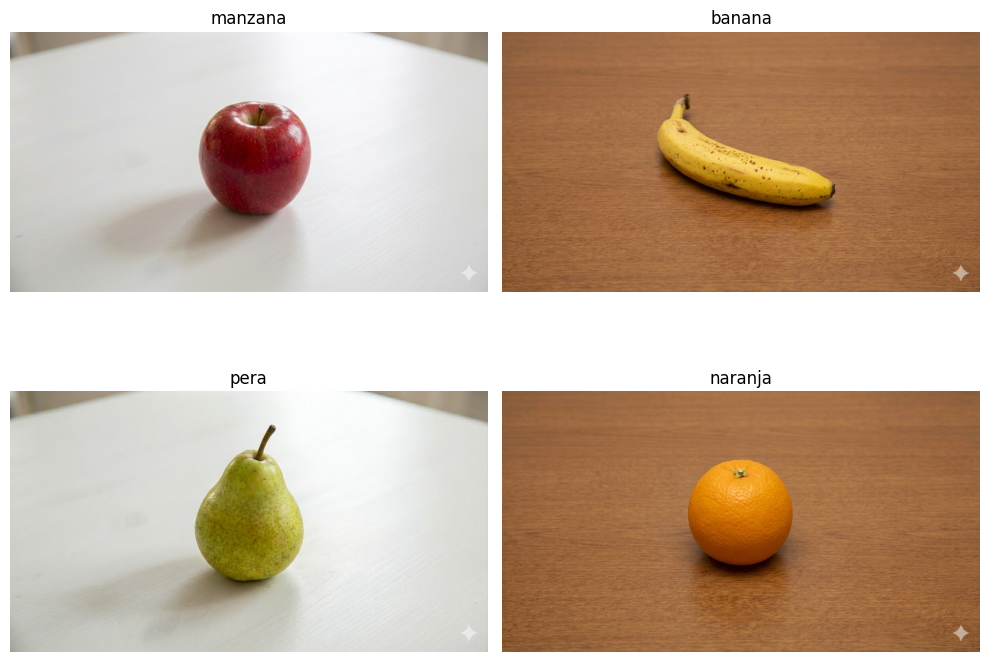

In [34]:
# Mostrar en una cuadrícula 2x2
fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.ravel()
for i, fruit in enumerate(FRUITS):
    ax = axes[i]
    img = images_rgb.get(fruit)
    if img is None:
        ax.text(0.5,0.5,f'No image for {fruit}', ha='center')
        ax.set_axis_off()
        continue
    ax.imshow(img)
    ax.set_title(fruit)
    ax.axis('off')
plt.tight_layout()
plt.show()

**Conversión a HSV y máscara por saturación**
Mostraremos para cada fruta la imagen original, la versión HSV (visualizada convertida a RGB para matplotlib) y la máscara binaria que usa el umbral de saturación.

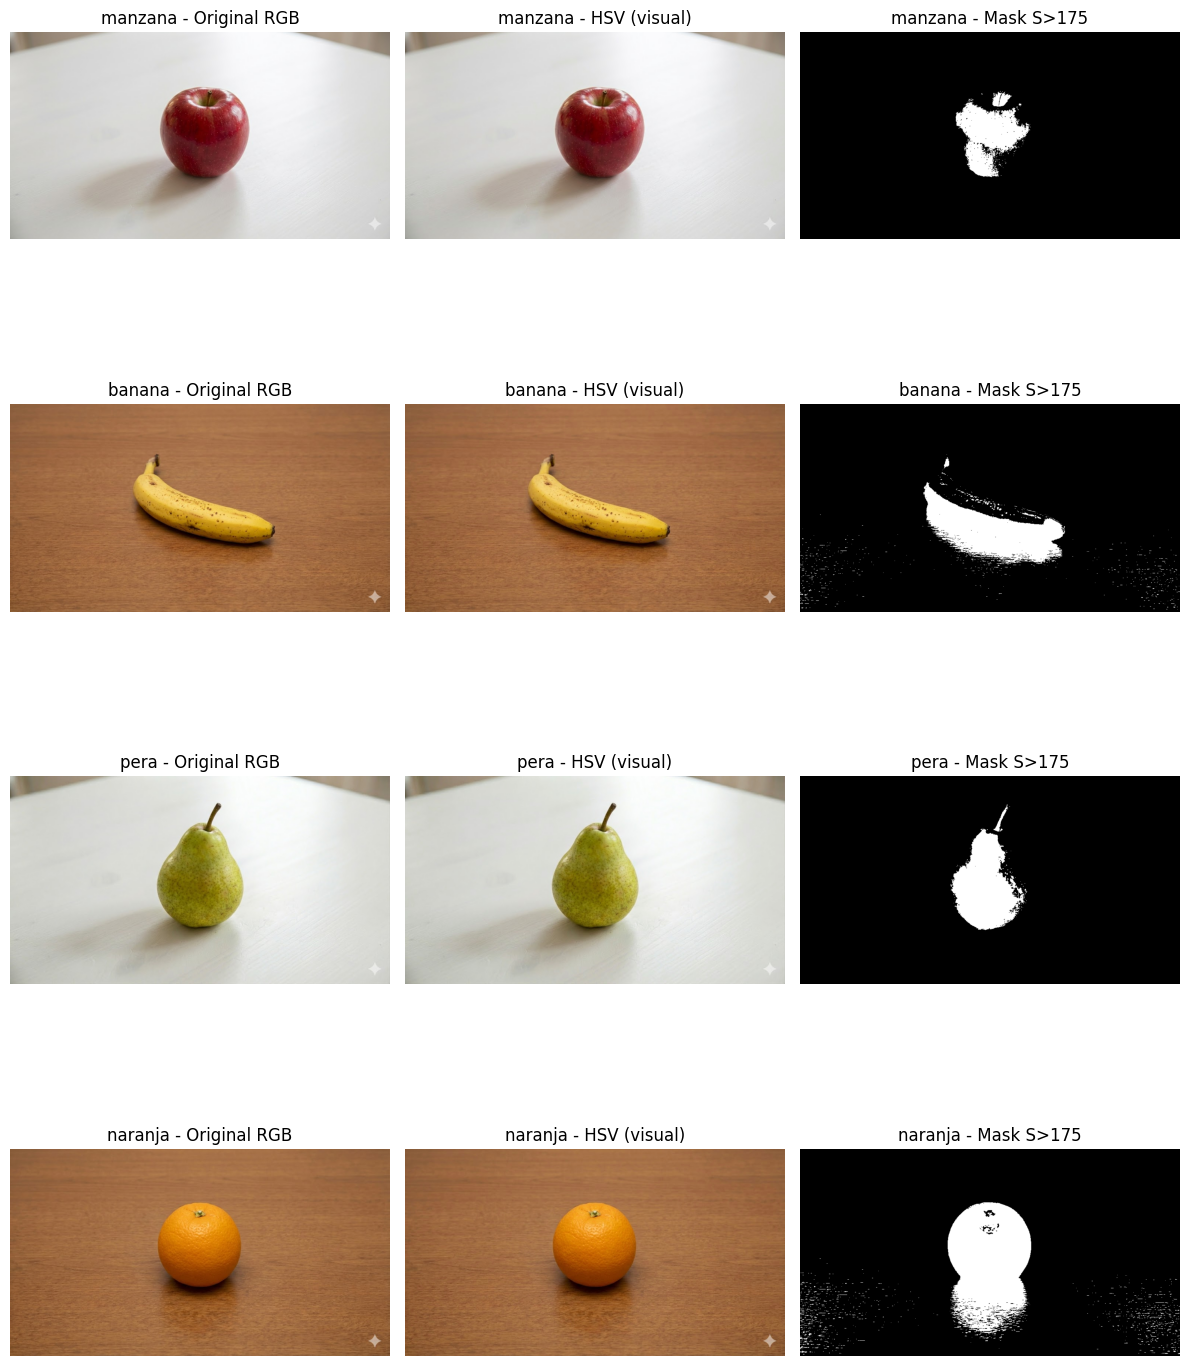

In [52]:
def hsv_to_display(hsv_img):
    # Para visualizar HSV con matplotlib convertimos a RGB (pasando por BGR como OpenCV espera)
    bgr = cv2.cvtColor(hsv_img, cv2.COLOR_HSV2BGR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb
SATURATION_THRESHOLD = 175


fig, axes = plt.subplots(len(FRUITS), 3, figsize=(12, 4*len(FRUITS)))
if len(FRUITS) == 1:
    axes = np.expand_dims(axes, 0)
for i, fruit in enumerate(FRUITS):
    rgb = images_rgb.get(fruit)
    hsv = images_hsv.get(fruit)
    ax_orig = axes[i,0]
    ax_hsv = axes[i,1]
    ax_mask = axes[i,2]
    if rgb is None or hsv is None:
        ax_orig.text(0.5,0.5,'No image', ha='center')
        ax_orig.axis('off')
        ax_hsv.axis('off')
        ax_mask.axis('off')
        continue
    # máscara por saturación
    S = hsv[:,:,1]
    mask = S > SATURATION_THRESHOLD

    ax_orig.imshow(rgb)
    ax_orig.set_title(f'{fruit} - Original RGB')
    ax_orig.axis('off')

    ax_hsv.imshow(hsv_to_display(hsv))
    ax_hsv.set_title(f'{fruit} - HSV (visual)')
    ax_hsv.axis('off')

    ax_mask.imshow(mask, cmap='gray')
    ax_mask.set_title(f'{fruit} - Mask S>{SATURATION_THRESHOLD}')
    ax_mask.axis('off')
plt.tight_layout()
plt.show()

**Extracción de características de color (HSV)**
Función que calcula H_mean, S_mean, V_mean sobre los píxeles que pasan la máscara de saturación. También calcula el Hue dominante (modo) usando histograma.

In [53]:
def extract_color_features(hsv_img, s_thresh=SATURATION_THRESHOLD, compute_hue_mode=True):
    # hsv_img: imagen en formato OpenCV HSV (H:0-179, S:0-255, V:0-255)
    H = hsv_img[:,:,0].astype(np.int32)
    S = hsv_img[:,:,1].astype(np.int32)
    V = hsv_img[:,:,2].astype(np.int32)

    mask = S > s_thresh
    # Si no hay píxeles, usamos todo el image para evitar NaNs
    if np.count_nonzero(mask) == 0:
        mask = np.ones_like(S, dtype=bool)

    H_vals = H[mask]
    S_vals = S[mask]
    V_vals = V[mask]

    H_mean = float(np.mean(H_vals))
    S_mean = float(np.mean(S_vals))
    V_mean = float(np.mean(V_vals))

    hue_mode = None
    if compute_hue_mode:
        # histograma del hue: 180 bins para cada valor posible (0-179)
        hist, bins = np.histogram(H_vals, bins=180, range=(0,180))
        max_idx = np.argmax(hist)
        hue_mode = int((bins[max_idx] + bins[max_idx+1]) / 2)

    # Devolvemos H_mean en la escala 0-179 (como OpenCV). Si quisieras grados, multiplicar por 2.
    return {'H_mean': H_mean, 'S_mean': S_mean, 'V_mean': V_mean, 'H_mode': hue_mode, 'mask': mask}

# Extraer características para cada fruta y construir un DataFrame
features = []
for fruit in FRUITS:
    hsv = images_hsv.get(fruit)
    if hsv is None:
        features.append({'fruit': fruit, 'H_mean': np.nan, 'S_mean': np.nan, 'V_mean': np.nan, 'H_mode': None})
        continue
    res = extract_color_features(hsv, s_thresh=SATURATION_THRESHOLD, compute_hue_mode=True)
    features.append({'fruit': fruit, 'H_mean': res['H_mean'], 'S_mean': res['S_mean'], 'V_mean': res['V_mean'], 'H_mode': res['H_mode']})

df_features = pd.DataFrame(features).set_index('fruit')
df_features

,H_mean,S_mean,V_mean,H_mode
fruit,,,,
manzana,115.325387,219.165025,100.446692,178
banana,16.869809,215.732462,141.833277,13
pera,26.780981,225.284109,124.334942,27
naranja,15.469442,226.353784,168.017523,14


**Implementación manual de K-Means (sin sklearn)**
Función `kmeans` que toma la matriz `X` (n_samples x n_features) y devuelve centroides y asignaciones.

In [54]:
def kmeans(X, k, max_iters=100, tol=1e-4, random_state=None):
    
    # X: ndarray (n_samples, n_features)
    # k: número de clusters
    # Devuelve: centroids (k, n_features), labels (n_samples,)
    if random_state is not None:
        np.random.seed(random_state)

    n_samples, n_features = X.shape
    # Inicializar centroides eligiendo aleatoriamente k índices distintos
    indices = np.random.choice(n_samples, k, replace=False)
    centroids = X[indices].astype(float)

    labels = np.zeros(n_samples, dtype=int)
    for it in range(max_iters):
        # Asignación: distancia euclídea al centroide más cercano
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)  # (n_samples, k)
        new_labels = np.argmin(dists, axis=1)

        # Recalcular centroides
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            members = X[new_labels == j]
            if len(members) == 0:
                # Si un cluster queda vacío, re-inicializamos su centroide aleatoriamente
                new_centroids[j] = X[np.random.randint(0, n_samples)]
            else:
                new_centroids[j] = np.mean(members, axis=0)

        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        labels = new_labels

        if shift <= tol:
            break
    return centroids, labels

# Preparar X con las columnas H_mean, S_mean, V_mean (descartar filas con NaN)
df_clean = df_features.dropna()
X = df_clean[['H_mean','S_mean','V_mean']].values
fruits_clean = df_clean.index.tolist()
X

array([[115.32538705, 219.16502463, 100.44669247],
       [ 16.86980885, 215.73246167, 141.83327673],
       [ 26.78098054, 225.28410895, 124.33494163],
       [ 15.46944225, 226.35378417, 168.01752252]])

**Ejecutar K-Means sobre las frutas**
Usaremos k=4 (una por fruta) si hay al menos 4 muestras válidas.

In [55]:
k = 4
if X.shape[0] < k:
    print('No hay suficientes muestras válidas para k=', k)
else:
    centroids, labels = kmeans(X, k=k, max_iters=200, tol=1e-4, random_state=42)
    print('Centroides finales (H_mean, S_mean, V_mean):')
    print(centroids)
    # Mapear asignaciones a nombres de frutas
    for fruit, label in zip(fruits_clean, labels):
        print(f'{fruit} -> cluster {label}')

    # Añadir columna de cluster al DataFrame para las filas limpias
    df_clustered = df_clean.copy()
    df_clustered['cluster'] = labels
    df_clustered

Centroides finales (H_mean, S_mean, V_mean):
[[ 16.86980885 215.73246167 141.83327673]
 [ 15.46944225 226.35378417 168.01752252]
 [115.32538705 219.16502463 100.44669247]
 [ 26.78098054 225.28410895 124.33494163]]
manzana -> cluster 2
banana -> cluster 0
pera -> cluster 3
naranja -> cluster 1


**Visualización de clusters**
Gráficos 2D y 3D para ver cómo se agrupan las frutas en el espacio de características.

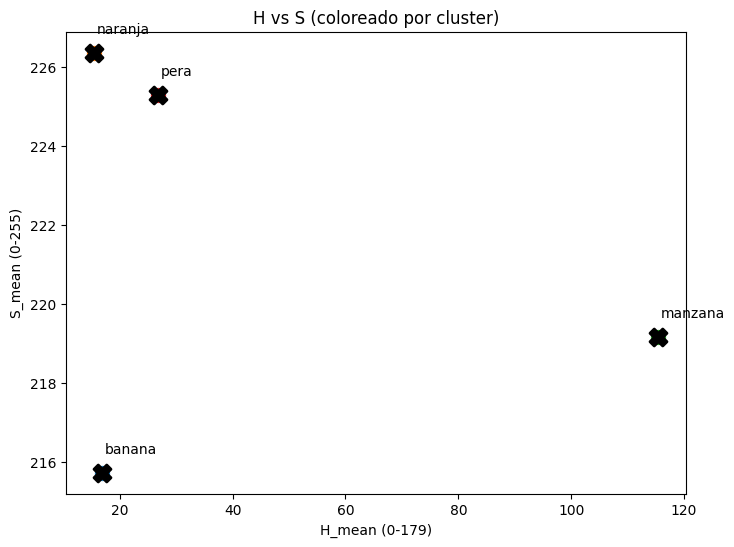

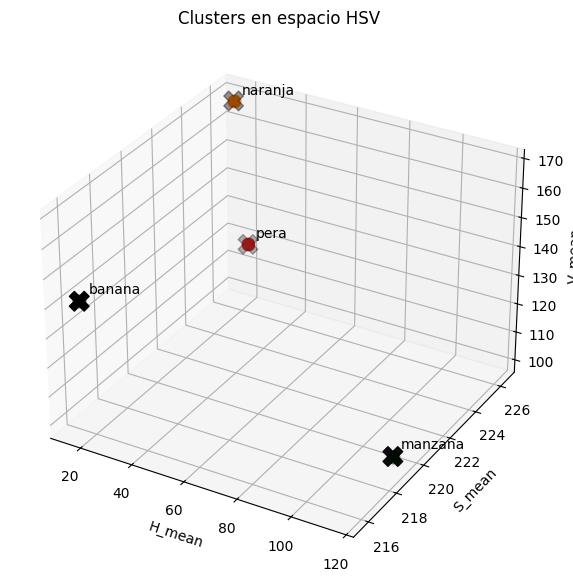

In [56]:
# Scatter 2D: H vs S
fig, ax = plt.subplots(figsize=(8,6))
colors = plt.cm.tab10(labels.astype(int) % 10) if 'labels' in globals() else 'C0'
for i, (fruit, row) in enumerate(df_clustered.iterrows()):
    ax.scatter(row['H_mean'], row['S_mean'], color=colors[i], s=100)
    ax.text(row['H_mean']+0.5, row['S_mean']+0.5, fruit)
ax.set_xlabel('H_mean (0-179)')
ax.set_ylabel('S_mean (0-255)')
ax.set_title('H vs S (coloreado por cluster)')
# dibujar centroides proyectados H vs S
for c in centroids:
    ax.scatter(c[0], c[1], marker='X', color='k', s=150, linewidths=2)
plt.show()

# Scatter 3D: H, S, V
fig = plt.figure(figsize=(9,7))
ax3 = fig.add_subplot(111, projection='3d')
for i, (fruit, row) in enumerate(df_clustered.iterrows()):
    ax3.scatter(row['H_mean'], row['S_mean'], row['V_mean'], color=colors[i], s=80)
    ax3.text(row['H_mean']+0.5, row['S_mean']+0.5, row['V_mean']+0.5, fruit)
# centroides 3D
ax3.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker='X', color='k', s=200)
ax3.set_xlabel('H_mean')
ax3.set_ylabel('S_mean')
ax3.set_zlabel('V_mean')
ax3.set_title('Clusters en espacio HSV')
plt.show()

**Conclusiones y siguientes pasos**
- Este notebook es para experimentación y visualización.
- Ajusta `SATURATION_THRESHOLD` si la máscara incluye demasiado fondo o recorta puntos de la fruta.
- Para una versión “seria”, considera: normalizar H en grados, agregar características (histogramas de color, textura), y usar más imágenes por clase.

Si querés, puedo: 1) ejecutar el notebook aquí (si lo deseás), 2) ajustar el umbral por fruta automáticamente, o 3) convertir H al rango 0-360 para interpretación.